                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -199.651
Date:                Mon, 05 Oct 2026   AIC                            411.302
Time:                        12:45:57   BIC                            420.634
Sample:                    01-01-1991   HQIC                           414.523
                         - 12-01-1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8788      0.227     -3.876      0.000      -1.323      -0.434
ar.L2         -0.2787      0.232     -1.203      0.229      -0.733       0.176
ar.L3         -0.0076      0.270     -0.028      0.9

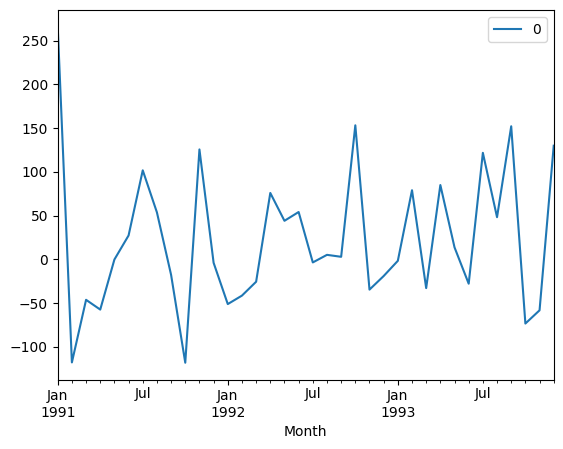

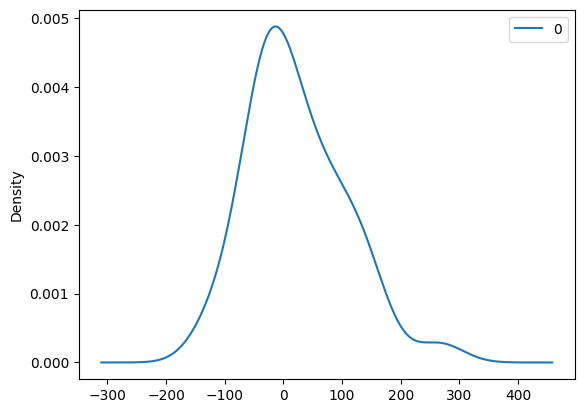

                0
count   36.000000
mean    22.459086
std     82.505331
min   -118.213281
25%    -33.308343
50%      1.361178
75%     76.704967
max    266.000000


In [5]:
# 7-1 ARIMA()함수를 호출하여 sales 데이터셋에 대한 예측
from pandas import read_csv #파이썬 판다스 라이브러리의 read_csv() 메서드를 사용하여 외부 TEXT 파일, CSV 파일을 불러와서 DataFrame으로 저장
from datetime import datetime   # pandas 대신 파이썬 기본 모듈에서
from pandas import DataFrame
from statsmodels.tsa.arima.model import ARIMA   # 새 경로
from matplotlib import pyplot

def parser(x): #시간을 표현하는 함수 정의
    return datetime.strptime('199'+x, '%Y-%m') #strptime()은 날짜와 시간 정보를 문자열로 바꾸어주는 메서드

#자전거 매출에 대한 CSV 데이터 호출
#series = read_csv('./data/sales.csv', header=0, parse_dates=[0], index_col=0, date_parser=parser).squeeze('columns')
series = read_csv('./data/sales.csv', header=0, index_col=0).squeeze('columns')
series.index = series.index.map(parser)   # date_parser 대신 직접 적용
series.index.freq = 'MS'                  # 월초 간격 명시

model = ARIMA(series, order=(5, 1, 0)) #ARIMA() 함수 호출
#model_fit = model.fit(disp=0) #모형을 적용할 때 많은 디버그 정보가 제공되는데 disp 인수를 0으로 설정하여 이 기능을 비활성화
model_fit = model.fit() #최근 모델은 disp=0 인자를 받지 않음
print(model_fit.summary()) #모델에 대한 정보 표시

residuals = DataFrame(model_fit.resid) #DataFrame에 모델에 대한 오차 정보를 residuals라는 변수에 저장
residuals.plot() #residuals 정보를 시각적으로 표현

pyplot.show()
residuals.plot(kind='kde') #KDE는 Kernel Density Estimation(커널 밀도 추정)의 약자로, 데이터가 어떤 값 근처에 얼마나 몰려 있는지를 부드러운 곡선
pyplot.show()
print(residuals.describe())

#model.fit() : statsmodels 라이브러리에서 모델을 데이터에 학습시키는 코드,
# disp=0은 학습 중 출력되는 로그를 끄는 옵션
# ARIMA, 로지스틱 회귀(Logit) 같은 statsmodels 모델은 fit()을 호출할 때 최적의 계수(파라미터)를 찾음

prediction=352.855343, expected=346.300000
prediction=277.398036, expected=329.700000
prediction=368.753734, expected=445.400000
prediction=331.773635, expected=325.900000
prediction=372.070429, expected=449.300000
prediction=360.020872, expected=411.300000
prediction=454.526230, expected=417.400000
prediction=388.690710, expected=545.500000
prediction=437.632447, expected=477.600000
prediction=516.437624, expected=687.000000
prediction=520.916190, expected=435.300000
prediction=675.594647, expected=587.300000
prediction=505.201016, expected=676.900000
Test MSE: 9118.818


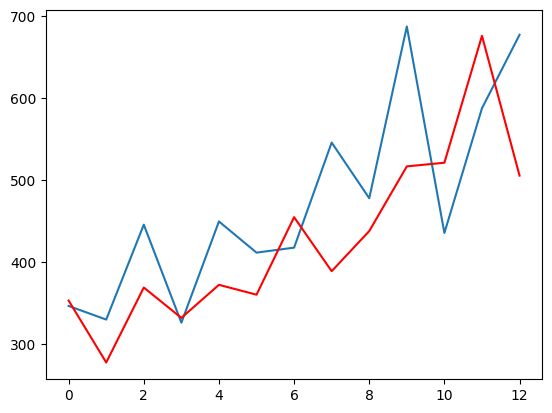

In [10]:
# 7-2 statsmodels 라이브러리를 이용한 sales 데이터셋 예측
import numpy as np
from pandas import read_csv
from datetime import datetime
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA   
from sklearn.metrics import mean_squared_error

def parser(x):
    return datetime.strptime('199'+x, '%Y-%m')

series = read_csv('./data/sales.csv', header=0, index_col=0).squeeze('columns')
series.index = series.index.map(parser)   # date_parser 대신 직접 적용 (인덱스를 날짜로 바꾸기)
series.index.freq = 'MS'                  # 월초 간격 명시 (날짜 간격 명시 ex. 1월 1일, 2월 1일...)

X = series.values #날짜 인덱스를 떼고 판매량 숫자만 넘파이 배열
X = np.nan_to_num(X) #빈 값(NaN)을 0으로 채우는 함수

size = int(len(X) * 0.66) #전체 36개월 중 앞쪽 66%(23개월)를 학습용,  뒤쪽 13개월을 테스트용
train, test = X[0:size], X[size:len(X)] #train과 test 데이터셋 분리 

history = [x for x in train] #훈련 데이터 넣기 history 변수에
predictions = list() #예측 값에 빈 리스트

for t in range(len(test)): #test 데이터셋의 길이(13)만큼 반복하여 수행
    model = ARIMA(history, order=(5, 1, 0)) #ARIMA() 함수 호출
    model_fit = model.fit()
    output = model_fit.forecast() #forecast() 메서드를 사용하여 예측 수행
    yhat = output[0]
    predictions.append(yhat)
    obs = test[t]
    history.append(obs)
    print('prediction=%f, expected=%f' % (yhat, obs)) #모델 실행 결과를 predicted로 출력하고, test로 분리해 둔 데이터를 expected로 사용하여 출력

error = mean_squared_error(test, predictions) #손실 함수로 평균 제곱 오차 사용
print('Test MSE: %.3f' % error)
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

#예측 값 : 빨간선, 정답지 : 파란색
#order=(5, 1, 0)은 ARIMA의 세 가지 설정값 (p, d, q)입니다.
#p=5 (AR): 직전 5개월의 값을 보고 다음 값을 예측
#d=1 (I): 값 자체가 아니라 "전월 대비 변화량"을 대상으로 분석 (추세가 있는 데이터를 평평하게 만들기 위해)
#q=0 (MA): 과거 예측 오차는 반영하지 않음